## Section 0 — Setup & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Column groups ──────────────────────────────────────────
CAT_COLS = ['TypeofContact', 'Occupation', 'Gender',
            'ProductPitched', 'MaritalStatus', 'Designation']
NUM_COLS = ['Age', 'DurationOfPitch', 'NumberOfPersonVisiting',
            'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips',
            'PitchSatisfactionScore', 'NumberOfChildrenVisiting', 'MonthlyIncome']
TARGET   = 'ProdTaken'

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load raw dataset (original, from tour_package.ipynb) ──
df_raw = pd.read_csv('tour_package.csv', encoding='utf-8-sig')
print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head()

Raw dataset shape: (4888, 20)


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
# ── Data Cleaning (mirrors data_cleaning.py) ──────────────
df = df_raw.copy()

# Fix gender typo
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing MonthlyIncome with Designation-wise median
df['MonthlyIncome'] = df.groupby('Designation')['MonthlyIncome'].transform(
    lambda s: s.fillna(s.median())
)

# Fill missing DurationOfPitch with median
df['DurationOfPitch'] = df['DurationOfPitch'].fillna(df['DurationOfPitch'].median())

# Fill missing NumberOfFollowups with median
df['NumberOfFollowups'] = df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].median())

# Fill missing PreferredPropertyStar with mode
df['PreferredPropertyStar'] = df['PreferredPropertyStar'].fillna(
    df['PreferredPropertyStar'].mode()[0]
)

# Cap MonthlyIncome outliers at 3xIQR upper fence
q1, q3 = df['MonthlyIncome'].quantile([0.25, 0.75])
upper_fence = q3 + 3 * (q3 - q1)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=upper_fence)

# Drop remaining NaN rows
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Cleaned dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Cleaned dataset shape: (4657, 20)
Missing values: 0


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


---
## Section 1 — Dataset Summary

In [4]:
summary = pd.DataFrame({
    'Metric': [
        'Total Rows', 'Total Columns',
        'Numeric Columns', 'Categorical Columns',
        'Binary Columns', 'Target Column',
        'Missing Values', 'Duplicate Rows',
    ],
    'Value': [
        df.shape[0], df.shape[1],
        len(NUM_COLS), len(CAT_COLS),
        2, TARGET,
        df.isnull().sum().sum(), df.duplicated().sum(),
    ],
})
display(summary)

,Metric,Value
0,Total Rows,4657
1,Total Columns,20
2,Numeric Columns,9
3,Categorical Columns,6
4,Binary Columns,2
5,Target Column,ProdTaken
6,Missing Values,0
7,Duplicate Rows,0


In [5]:
print('Column data types:')
print(df.dtypes)
print()
print('Categorical unique values:')
for c in CAT_COLS:
    print(f'  {c}: {sorted(df[c].unique().tolist())}')

Column data types:
CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

Categorical unique values:
  TypeofContact: ['Company Invited', 'Self Enquiry']
  Occupation: ['Free Lancer', 'Large Business', 'Salaried', 'Small Business']
  Gender: ['Female', 'Male']
  ProductPitched: ['Basic', 'Deluxe', 'King', 'Standard', '

---
## Section 2 — Descriptive Statistics (Numeric Features)

In [6]:
desc = df[NUM_COLS].describe().T.round(2)
desc['skew']     = df[NUM_COLS].skew().round(3)
desc['kurtosis'] = df[NUM_COLS].kurt().round(3)
display(desc)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,4657.0,37.13,8.95,18.0,31.0,36.0,42.0,61.0,0.474,-0.163
DurationOfPitch,4657.0,15.43,8.35,5.0,9.0,13.0,19.0,127.0,1.842,12.904
NumberOfPersonVisiting,4657.0,2.89,0.73,1.0,2.0,3.0,3.0,5.0,0.046,-0.777
NumberOfFollowups,4657.0,3.70,1.00,1.0,3.0,4.0,4.0,6.0,-0.355,0.624
PreferredPropertyStar,4657.0,3.58,0.80,3.0,3.0,3.0,4.0,5.0,0.907,-0.820
NumberOfTrips,4657.0,3.23,1.85,1.0,2.0,3.0,4.0,22.0,1.478,6.245
PitchSatisfactionScore,4657.0,3.07,1.36,1.0,2.0,3.0,4.0,5.0,-0.126,-1.100
NumberOfChildrenVisiting,4657.0,1.17,0.86,0.0,1.0,1.0,2.0,3.0,0.285,-0.599
MonthlyIncome,4657.0,22961.32,4378.08,1000.0,20346.0,22104.0,24980.0,40244.0,0.942,1.047


---
## Section 3 — Target Distribution

In [7]:
vc = df[TARGET].value_counts().reset_index()
vc.columns = ['ProdTaken', 'Count']
vc['Percentage'] = (vc['Count'] / len(df) * 100).round(2)
vc['Label'] = vc['ProdTaken'].map({0: 'Not Taken', 1: 'Taken'})
display(vc)

taken_count    = df[TARGET].sum()
not_taken_count= len(df) - taken_count
conv_rate      = df[TARGET].mean() * 100
imbalance      = not_taken_count / taken_count

print(f'Conversion Rate       : {conv_rate:.2f}%')
print(f'Class Imbalance (0:1) : {imbalance:.2f}:1')

,ProdTaken,Count,Percentage,Label
0,0,3759,80.72,Not Taken
1,1,898,19.28,Taken


Conversion Rate       : 19.28%
Class Imbalance (0:1) : 4.19:1


---
## Section 4 — Conversion Rate by Categorical Features

In [8]:
conv_all_rows = []
for col in CAT_COLS:
    grp = (
        df.groupby(col)[TARGET]
        .agg(Total='count', Sold='sum')
        .assign(
            ConversionRate=lambda x: (x['Sold'] / x['Total'] * 100).round(2),
            NotSold=lambda x: x['Total'] - x['Sold'],
        )
        .sort_values('ConversionRate', ascending=False)
        .reset_index()
    )
    grp.insert(0, 'Feature', col)
    grp.rename(columns={col: 'Category'}, inplace=True)
    conv_all_rows.append(grp)
    print(f'\n--- {col} ---')
    display(grp)

conv_df = pd.concat(conv_all_rows, ignore_index=True)


--- TypeofContact ---


,Feature,Category,Total,Sold,ConversionRate,NotSold
0,TypeofContact,Company Invited,1372,308,22.45,1064
1,TypeofContact,Self Enquiry,3285,590,17.96,2695



--- Occupation ---


,Feature,Category,Total,Sold,ConversionRate,NotSold
0,Occupation,Free Lancer,2,2,100.00,0
1,Occupation,Large Business,427,119,27.87,308
2,Occupation,Small Business,1975,372,18.84,1603
3,Occupation,Salaried,2253,405,17.98,1848



--- Gender ---


...

,Feature,Category,Total,Sold,ConversionRate,NotSold
0,ProductPitched,Basic,1826,543,29.74,1283
1,ProductPitched,Standard,740,122,16.49,618
2,ProductPitched,Deluxe,1714,201,11.73,1513
3,ProductPitched,King,127,13,10.24,114
4,ProductPitched,Super Deluxe,250,19,7.60,231



--- MaritalStatus ---


,Feature,Category,Total,Sold,ConversionRate,NotSold
0,MaritalStatus,Single,865,294,33.99,571
1,MaritalStatus,Unmarried,682,166,24.34,516
2,MaritalStatus,Married,2218,317,14.29,1901
3,MaritalStatus,Divorced,892,121,13.57,771



--- Designation ---


,Feature,Category,Total,Sold,ConversionRate,NotSold
0,Designation,Executive,1826,543,29.74,1283
1,Designation,Senior Manager,740,122,16.49,618
2,Designation,Manager,1714,201,11.73,1513
3,Designation,VP,127,13,10.24,114
4,Designation,AVP,250,19,7.60,231


---
## Section 5 — Numeric Feature Means: Taken vs Not Taken

In [9]:
grp_means = df.groupby(TARGET)[NUM_COLS].mean().round(2)
grp_means.index = ['Not Taken (0)', 'Taken (1)']
diff = grp_means.loc['Taken (1)'] - grp_means.loc['Not Taken (0)']
grp_means.loc['Difference (Taken - Not)'] = diff.round(2)
display(grp_means.T)

,Not Taken (0),Taken (1),Difference (Taken - Not)
Age,37.75,34.55,-3.20
DurationOfPitch,15.12,16.72,1.60
NumberOfPersonVisiting,2.89,2.91,0.02
NumberOfFollowups,3.64,3.94,0.30
PreferredPropertyStar,3.54,3.73,0.19
NumberOfTrips,3.21,3.29,0.08
PitchSatisfactionScore,3.04,3.23,0.19
NumberOfChildrenVisiting,1.17,1.19,0.02
MonthlyIncome,23227.47,21847.23,-1380.24


---
## Section 6 — Pearson Correlation with Target (ProdTaken)

In [10]:
corr_series = df[NUM_COLS + [TARGET]].corr()[TARGET].drop(TARGET)
corr_df = pd.DataFrame({
    'Feature':         corr_series.index,
    'Correlation':     corr_series.round(4).values,
    'Abs_Correlation': corr_series.abs().round(4).values,
    'Direction':       ['Positive' if v > 0 else 'Negative' for v in corr_series.values],
    'Strength':        [
        'Strong'   if abs(v) >= 0.3 else
        'Moderate' if abs(v) >= 0.15 else
        'Weak'     if abs(v) >= 0.05 else 'Negligible'
        for v in corr_series.values
    ],
}).sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
display(corr_df)

,Feature,Correlation,Abs_Correlation,Direction,Strength
0,Age,-0.1407,0.1407,Negative,Weak
1,MonthlyIncome,-0.1244,0.1244,Negative,Weak
2,NumberOfFollowups,0.1176,0.1176,Positive,Weak
3,PreferredPropertyStar,0.0975,0.0975,Positive,Weak
4,DurationOfPitch,0.0756,0.0756,Positive,Weak
5,PitchSatisfactionScore,0.0563,0.0563,Positive,Weak
6,NumberOfTrips,0.0177,0.0177,Positive,Negligible
7,NumberOfPersonVisiting,0.0142,0.0142,Positive,Negligible
8,NumberOfChildrenVisiting,0.0108,0.0108,Positive,Negligible


---
## Section 7 — Outlier Detection (IQR Method)

In [11]:
outlier_rows = []
for col in NUM_COLS:
    q1   = df[col].quantile(0.25)
    q3   = df[col].quantile(0.75)
    iqr  = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'Feature':       col,
        'Q1':            round(q1, 2),
        'Q3':            round(q3, 2),
        'IQR':           round(iqr, 2),
        'Lower_Fence':   round(lower, 2),
        'Upper_Fence':   round(upper, 2),
        'Outlier_Count': int(n_out),
        'Outlier_%':     round(n_out / len(df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('Outlier_Count', ascending=False).reset_index(drop=True)
display(outlier_df)

,Feature,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_%
0,NumberOfFollowups,3.0,4.0,1.0,1.5,5.5,303,6.51
1,MonthlyIncome,20346.0,24980.0,4634.0,13395.0,31931.0,268,5.75
2,NumberOfTrips,2.0,4.0,2.0,-1.0,7.0,108,2.32
3,DurationOfPitch,9.0,19.0,10.0,-6.0,34.0,107,2.30
4,Age,31.0,42.0,11.0,14.5,58.5,77,1.65
5,NumberOfPersonVisiting,2.0,3.0,1.0,0.5,4.5,3,0.06
6,PreferredPropertyStar,3.0,4.0,1.0,1.5,5.5,0,0.00
7,PitchSatisfactionScore,2.0,4.0,2.0,-1.0,7.0,0,0.00
8,NumberOfChildrenVisiting,1.0,2.0,1.0,-0.5,3.5,0,0.00


---
## Section 8 — Cross-tab: ProductPitched × MaritalStatus (Conversion Rate %)

In [12]:
ct8 = df.groupby(['ProductPitched', 'MaritalStatus'])[TARGET].mean().unstack() * 100
ct8 = ct8.round(1)
ct8.columns.name = 'MaritalStatus'
print('Values are Conversion Rate (%)')
display(ct8.style.background_gradient(cmap='Blues', axis=None))

Values are Conversion Rate (%)


MaritalStatus,Divorced,Married,Single,Unmarried
ProductPitched,,,,
Basic,17.900000,22.800000,44.800000,40.400000
Deluxe,9.600000,7.900000,20.000000,18.300000
King,14.300000,5.900000,16.100000,nan
Standard,18.300000,14.500000,20.400000,18.200000
Super Deluxe,0.000000,6.500000,15.000000,33.300000


---
## Section 9 — Cross-tab: Designation × Passport (Conversion Rate %)

In [13]:
ct9 = df.groupby(['Designation', 'Passport'])[TARGET].mean().unstack() * 100
ct9 = ct9.round(1).rename(columns={0: 'No Passport', 1: 'Has Passport'})
print('Values are Conversion Rate (%)')
display(ct9.style.background_gradient(cmap='Greens', axis=None))

Values are Conversion Rate (%)


Passport,No Passport,Has Passport
Designation,,
AVP,4.700000,13.600000
Executive,17.700000,56.500000
Manager,8.300000,20.700000
Senior Manager,14.100000,22.500000
VP,6.200000,22.600000


---
## Section 10 — Monthly Income Analysis by Designation

In [14]:
inc = (
    df.groupby('Designation')['MonthlyIncome']
    .agg(Count='count', Mean='mean', Median='median', Std='std', Min='min', Max='max')
    .round(0)
    .sort_values('Median')
    .reset_index()
)
display(inc)

,Designation,Count,Mean,Median,Std,Min,Max
0,Executive,1826,19855.0,20689.0,2350.0,16009.0,40244.0
1,Manager,1714,22640.0,22922.0,2350.0,1000.0,38525.0
2,Senior Manager,740,26613.0,26416.0,2759.0,17372.0,38395.0
3,AVP,250,30972.0,31795.0,2250.0,17705.0,35563.0
4,VP,127,34913.0,34246.0,2785.0,17517.0,38677.0


---
## Section 11 — Follow-up Count: Conversion & Income Pivot

In [15]:
fu = (
    df.groupby('NumberOfFollowups')
    .agg(
        Customers      =('ProdTaken', 'count'),
        Sold           =('ProdTaken', 'sum'),
        ConversionRate =('ProdTaken', lambda s: round(s.mean() * 100, 2)),
        MeanIncome     =('MonthlyIncome', lambda s: round(s.mean(), 0)),
        MedianAge      =('Age', 'median'),
    )
    .reset_index()
)
display(fu)
print('Key insight: More follow-ups consistently drives higher conversion rate.')

,NumberOfFollowups,Customers,Sold,ConversionRate,MeanIncome,MedianAge
0,1.0,171,20,11.70,21227.0,36.0
1,2.0,219,23,10.50,23489.0,36.0
2,3.0,1440,239,16.60,21884.0,36.0
3,4.0,1976,378,19.13,23356.0,36.0
4,5.0,719,186,25.87,23980.0,36.0
5,6.0,132,52,39.39,24628.0,35.0


Key insight: More follow-ups consistently drives higher conversion rate.


---
## Section 12 — Age Band Conversion Analysis

In [16]:
df_age = df.copy()
df_age['AgeBand'] = pd.cut(
    df_age['Age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)
age_df = (
    df_age.groupby('AgeBand', observed=True)
    .agg(
        Count          =('ProdTaken', 'count'),
        Sold           =('ProdTaken', 'sum'),
        ConversionRate =('ProdTaken', lambda s: round(s.mean() * 100, 2)),
        MeanIncome     =('MonthlyIncome', lambda s: round(s.mean(), 0)),
        MeanAge        =('Age', lambda s: round(s.mean(), 1)),
        PassportRate   =('Passport', lambda s: round(s.mean() * 100, 1)),
    )
    .reset_index()
)
display(age_df)

,AgeBand,Count,Sold,ConversionRate,MeanIncome,MeanAge,PassportRate
0,18-25,343,142,41.40,19530.0,22.3,32.4
1,26-35,1779,394,22.15,21796.0,31.0,26.5
2,36-45,1693,232,13.70,23260.0,39.3,30.3
3,46-55,665,93,13.98,26357.0,50.0,30.4
4,56+,177,37,20.90,25707.0,58.1,39.0


---
## Section 13 — Chi-Square Test: Categorical Features vs ProdTaken

> Tests whether each categorical feature is **statistically independent** of the purchase decision.  
> p < 0.05 → feature is significantly linked to conversion.

In [17]:
chi_rows = []
for col in CAT_COLS:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    chi_rows.append({
        'Feature':    col,
        'Chi2':       round(chi2, 3),
        'p_value':    round(p, 6),
        'df':         dof,
        'Significant': 'YES ***' if p < 0.001 else
                       'YES **'  if p < 0.01  else
                       'YES *'   if p < 0.05  else 'NO',
        'Conclusion': 'Dependent (linked to purchase)' if p < 0.05
                      else 'Independent (no significant link)',
    })

chi_df = pd.DataFrame(chi_rows).sort_values('p_value').reset_index(drop=True)
display(chi_df)

,Feature,Chi2,p_value,df,Significant,Conclusion
0,ProductPitched,223.408,0.000000,4,YES ***,Dependent (linked to purchase)
1,MaritalStatus,185.620,0.000000,3,YES ***,Dependent (linked to purchase)
2,Designation,223.408,0.000000,4,YES ***,Dependent (linked to purchase)
3,Occupation,31.322,0.000001,3,YES ***,Dependent (linked to purchase)
4,TypeofContact,12.241,0.000468,1,YES ***,Dependent (linked to purchase)
5,Gender,4.700,0.030170,1,YES *,Dependent (linked to purchase)


---
## Section 14 — Independent T-Test: Numeric Features vs ProdTaken

> Tests whether the **mean** of each numeric feature differs significantly  
> between customers who bought (Taken=1) and those who didn't (Taken=0).  
> Uses Welch's t-test (equal_var=False).

In [18]:
taken     = df[df[TARGET] == 1]
not_taken = df[df[TARGET] == 0]

ttest_rows = []
for col in NUM_COLS:
    t_stat, p_val      = stats.ttest_ind(taken[col], not_taken[col], equal_var=False)
    mean_taken         = round(taken[col].mean(), 3)
    mean_not_taken     = round(not_taken[col].mean(), 3)
    ttest_rows.append({
        'Feature':       col,
        'Mean_Taken':    mean_taken,
        'Mean_NotTaken': mean_not_taken,
        'Difference':    round(mean_taken - mean_not_taken, 3),
        'T_Statistic':   round(t_stat, 3),
        'p_value':       round(p_val, 6),
        'Significant':   'YES ***' if p_val < 0.001 else
                         'YES **'  if p_val < 0.01  else
                         'YES *'   if p_val < 0.05  else 'NO',
    })

ttest_df = pd.DataFrame(ttest_rows).sort_values('p_value').reset_index(drop=True)
display(ttest_df)

,Feature,Mean_Taken,Mean_NotTaken,Difference,T_Statistic,p_value,Significant
0,Age,34.555,37.746,-3.191,-9.067,0.000000,YES ***
1,DurationOfPitch,16.722,15.121,1.601,5.180,0.000000,YES ***
2,NumberOfFollowups,3.939,3.640,0.299,8.035,0.000000,YES ***
3,PreferredPropertyStar,3.735,3.538,0.197,6.292,0.000000,YES ***
4,MonthlyIncome,21847.227,23227.468,-1380.241,-8.891,0.000000,YES ***
5,PitchSatisfactionScore,3.231,3.036,0.195,3.923,0.000092,YES ***
6,NumberOfTrips,3.294,3.211,0.083,1.117,0.264315,NO
7,NumberOfPersonVisiting,2.913,2.887,0.026,0.997,0.318782,NO
8,NumberOfChildrenVisiting,1.192,1.168,0.024,0.735,0.462720,NO


---
## Section 15 — Key Findings & Business Insights

In [19]:
best_cat_conv = {}
for col in CAT_COLS:
    g = df.groupby(col)[TARGET].mean()
    best_cat_conv[col] = (g.idxmax(), round(g.max() * 100, 1))

sig_chi   = ', '.join(chi_df[chi_df['p_value'] < 0.05]['Feature'].tolist())
sig_ttest = ', '.join(ttest_df[ttest_df['p_value'] < 0.05]['Feature'].tolist())

print(f'''
{'='*65}
DATASET
  Total customers     : {len(df):,}
  Packages sold       : {df[TARGET].sum():,}
  Conversion rate     : {df[TARGET].mean()*100:.2f}%
  Class imbalance     : {(df[TARGET]==0).sum()}:{df[TARGET].sum()} (Not Taken : Taken)

DEMOGRAPHIC INSIGHTS
  Younger customers buy more  (Taken mean age={taken["Age"].mean():.1f} vs Not Taken={not_taken["Age"].mean():.1f})
  Gender gap  : Male {df[df["Gender"]=="Male"][TARGET].mean()*100:.1f}%  vs  Female {df[df["Gender"]=="Female"][TARGET].mean()*100:.1f}%

TOP CONVERTING SEGMENTS
  Occupation    : {best_cat_conv["Occupation"][0]} ({best_cat_conv["Occupation"][1]}%)
  Marital Status: {best_cat_conv["MaritalStatus"][0]} ({best_cat_conv["MaritalStatus"][1]}%)
  Designation   : {best_cat_conv["Designation"][0]} ({best_cat_conv["Designation"][1]}%)
  Product       : {best_cat_conv["ProductPitched"][0]} ({best_cat_conv["ProductPitched"][1]}%)
  Contact Type  : {best_cat_conv["TypeofContact"][0]} ({best_cat_conv["TypeofContact"][1]}%)

PASSPORT & CAR EFFECT
  Passport holders : {df[df["Passport"]==1][TARGET].mean()*100:.1f}%  vs  {df[df["Passport"]==0][TARGET].mean()*100:.1f}% (no passport)
  Own car          : {df[df["OwnCar"]==1][TARGET].mean()*100:.1f}%  vs  {df[df["OwnCar"]==0][TARGET].mean()*100:.1f}% (no car)

PITCH QUALITY
  Followups  — Taken={taken["NumberOfFollowups"].mean():.2f} vs Not Taken={not_taken["NumberOfFollowups"].mean():.2f}
  Pitch Score— Taken={taken["PitchSatisfactionScore"].mean():.2f} vs Not Taken={not_taken["PitchSatisfactionScore"].mean():.2f}
  Duration   — Taken={taken["DurationOfPitch"].mean():.1f} min vs Not Taken={not_taken["DurationOfPitch"].mean():.1f} min

INCOME
  Taken group earns LESS: INR {taken["MonthlyIncome"].mean():,.0f} vs INR {not_taken["MonthlyIncome"].mean():,.0f} (Not Taken)
  Lower-income customers are more price-sensitive and motivated by travel packages.

STATISTICAL SIGNIFICANCE
  Chi-Square (p<0.05) : {sig_chi}
  T-Test     (p<0.05) : {sig_ttest}
{'='*65}
''')


DATASET
  Total customers     : 4,657
  Packages sold       : 898
  Conversion rate     : 19.28%
  Class imbalance     : 3759:898 (Not Taken : Taken)

DEMOGRAPHIC INSIGHTS
  Younger customers buy more  (Taken mean age=34.6 vs Not Taken=37.7)
  Gender gap  : Male 20.3%  vs  Female 17.7%

TOP CONVERTING SEGMENTS
  Occupation    : Free Lancer (100.0%)
  Marital Status: Single (34.0%)
  Designation   : Executive (29.7%)
  Product       : Basic (29.7%)
  Contact Type  : Company Invited (22.4%)

PASSPORT & CAR EFFECT
  Passport holders : 35.4%  vs  12.6% (no passport)
  Own car          : 18.9%  vs  19.9% (no car)

PITCH QUALITY
  Followups  — Taken=3.94 vs Not Taken=3.64
  Pitch Score— Taken=3.23 vs Not Taken=3.04
  Duration   — Taken=16.7 min vs Not Taken=15.1 min

INCOME
  Taken group earns LESS: INR 21,847 vs INR 23,227 (Not Taken)
  Lower-income customers are more price-sensitive and motivated by travel packages.

STATISTICAL SIGNIFICANCE
  Chi-Square (p<0.05) : ProductPitched, Marital

---
## Section 17 — Charts & Visualisations

All charts use `matplotlib` and `seaborn` — no extra installs needed.
Every chart reflects the **filtered, cleaned** dataset.


In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9,
                     'ytick.labelsize': 9})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
PURP   = '#7C3AED'
PAL    = [BLUE, ORANGE, GREEN, PURP, '#0891B2', '#CA8A04', '#DB2777']
print('Chart setup done.')

Chart setup done.


### Chart 1 — Target Distribution (Donut + Bar)

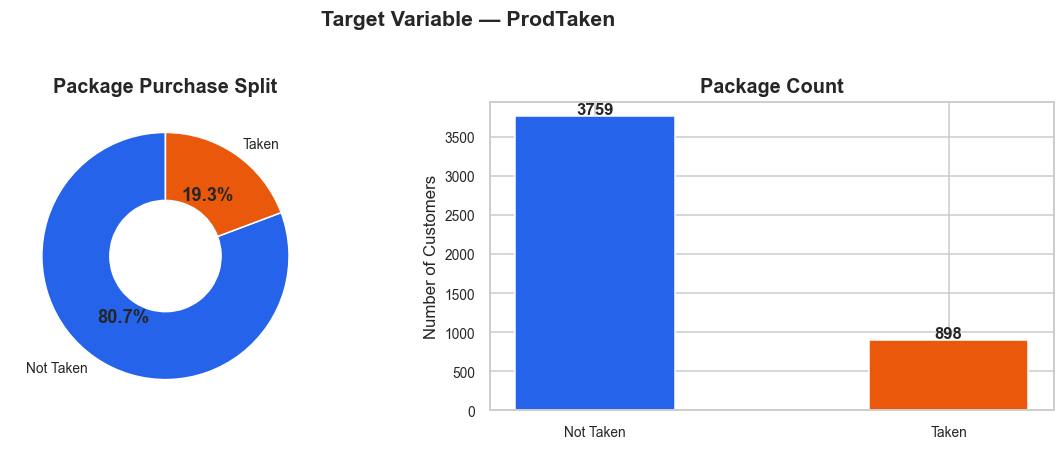

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Donut
vc2 = df[TARGET].value_counts()
labels = ['Not Taken', 'Taken']
colors = [BLUE, ORANGE]
wedges, texts, autotexts = axes[0].pie(
    [vc2[0], vc2[1]], labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white'))
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Package Purchase Split', fontweight='bold')

# Bar
axes[1].bar(labels, [vc2[0], vc2[1]], color=colors, width=0.45, edgecolor='white')
axes[1].set_title('Package Count', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate([vc2[0], vc2[1]]):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Target Variable — ProdTaken', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart 2 — Numeric Feature Distributions (Histogram + KDE Grid)

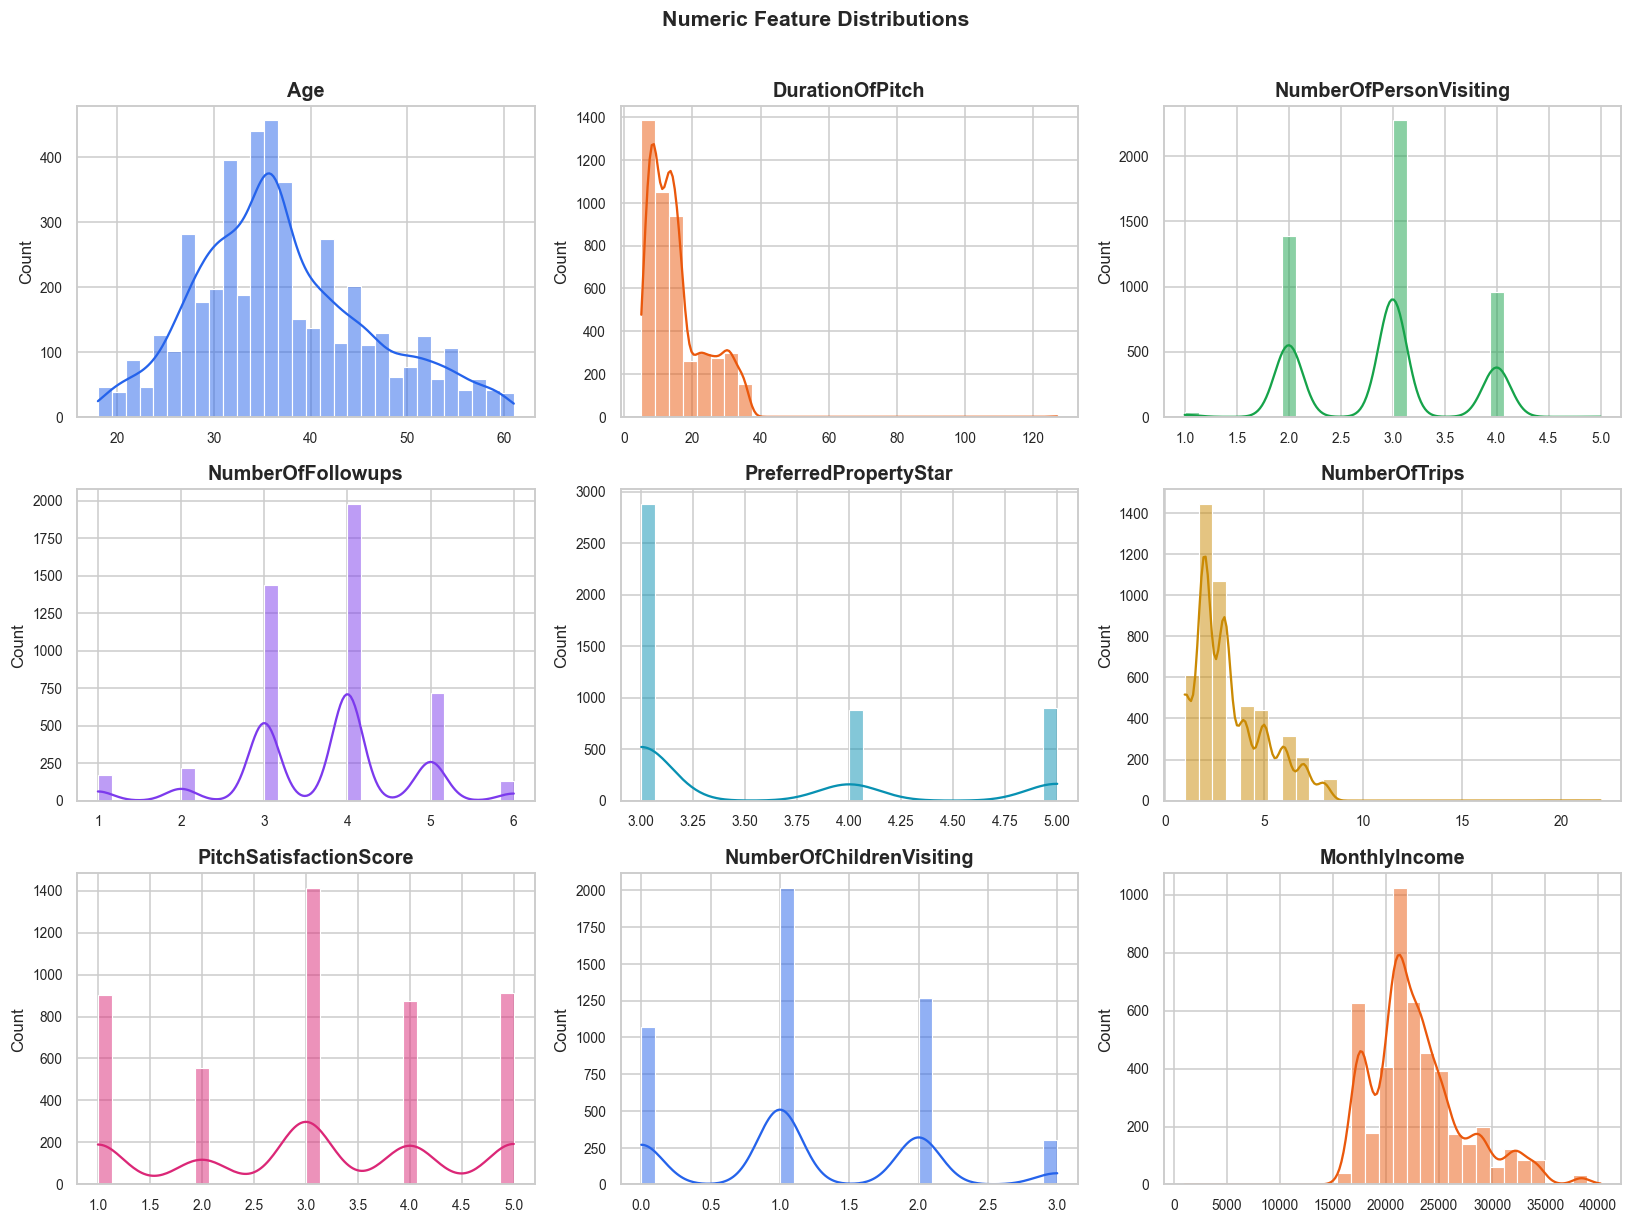

In [22]:
num_plot = ['Age', 'DurationOfPitch', 'NumberOfPersonVisiting',
            'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips',
            'PitchSatisfactionScore', 'NumberOfChildrenVisiting', 'MonthlyIncome']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(num_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color=PAL[i % len(PAL)],
                 bins=30, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Chart 3 — Boxplots (Outlier Detection)

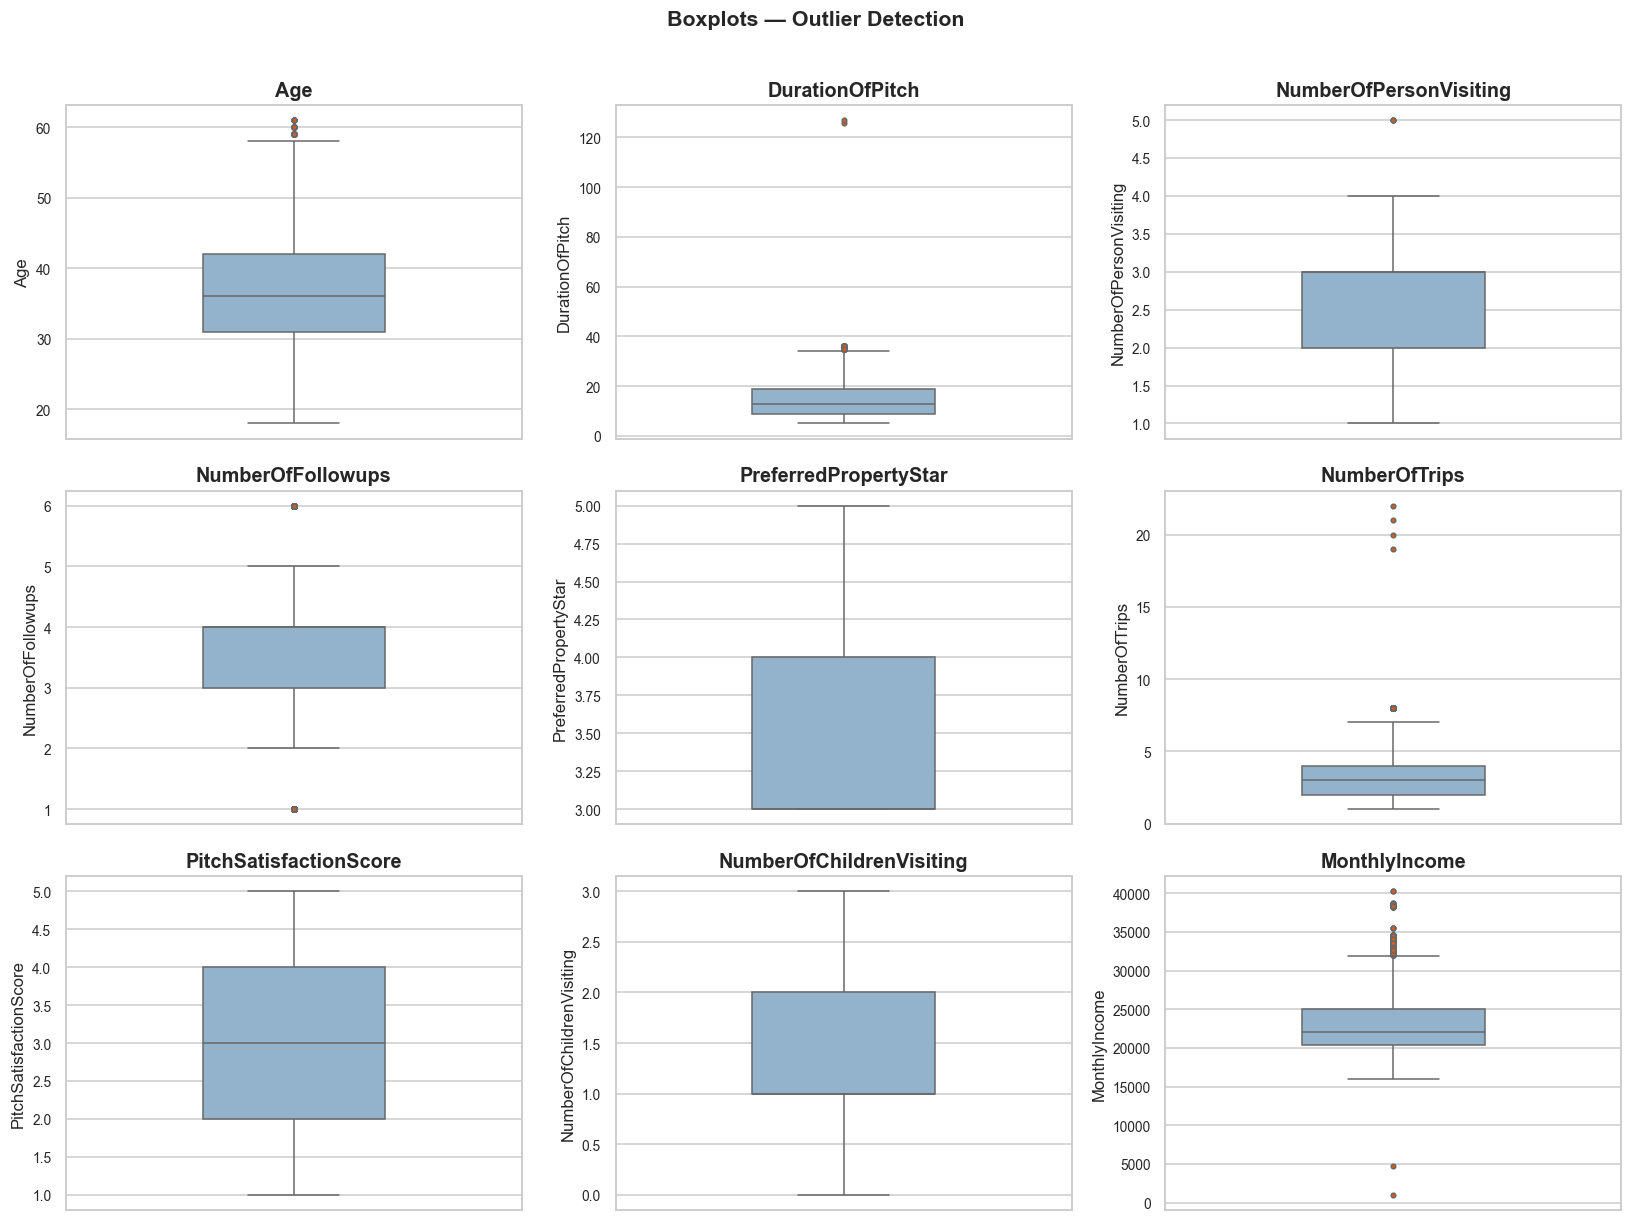

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(num_plot):
    sns.boxplot(y=df[col], ax=axes[i], color='#88b4d4', width=0.4,
                flierprops=dict(marker='o', markerfacecolor=ORANGE, markersize=3))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Chart 4 — Categorical Feature Distributions

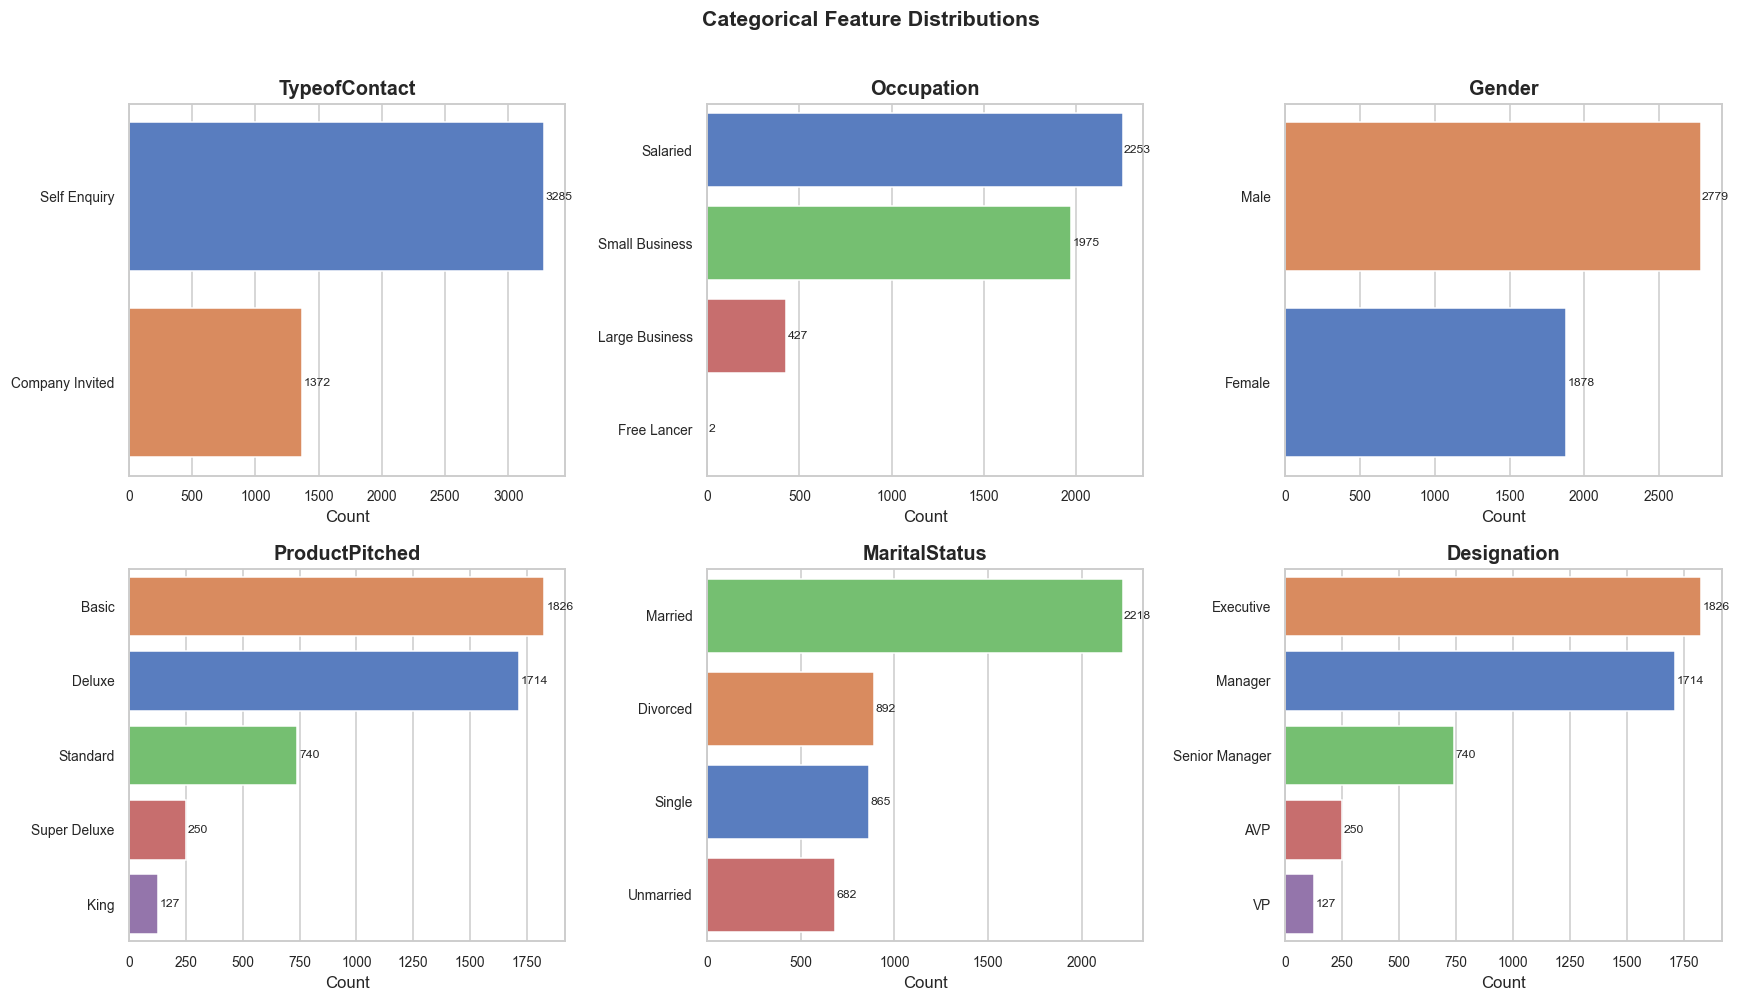

In [24]:
cat_plot = ['TypeofContact', 'Occupation', 'Gender',
            'ProductPitched', 'MaritalStatus', 'Designation']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, hue=col, ax=axes[i],
                  palette='muted', edgecolor='white', legend=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
    for bar in axes[i].patches:
        axes[i].text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
                     f'{int(bar.get_width())}', va='center', fontsize=8)
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Chart 5 — Conversion Rate by Each Categorical Feature

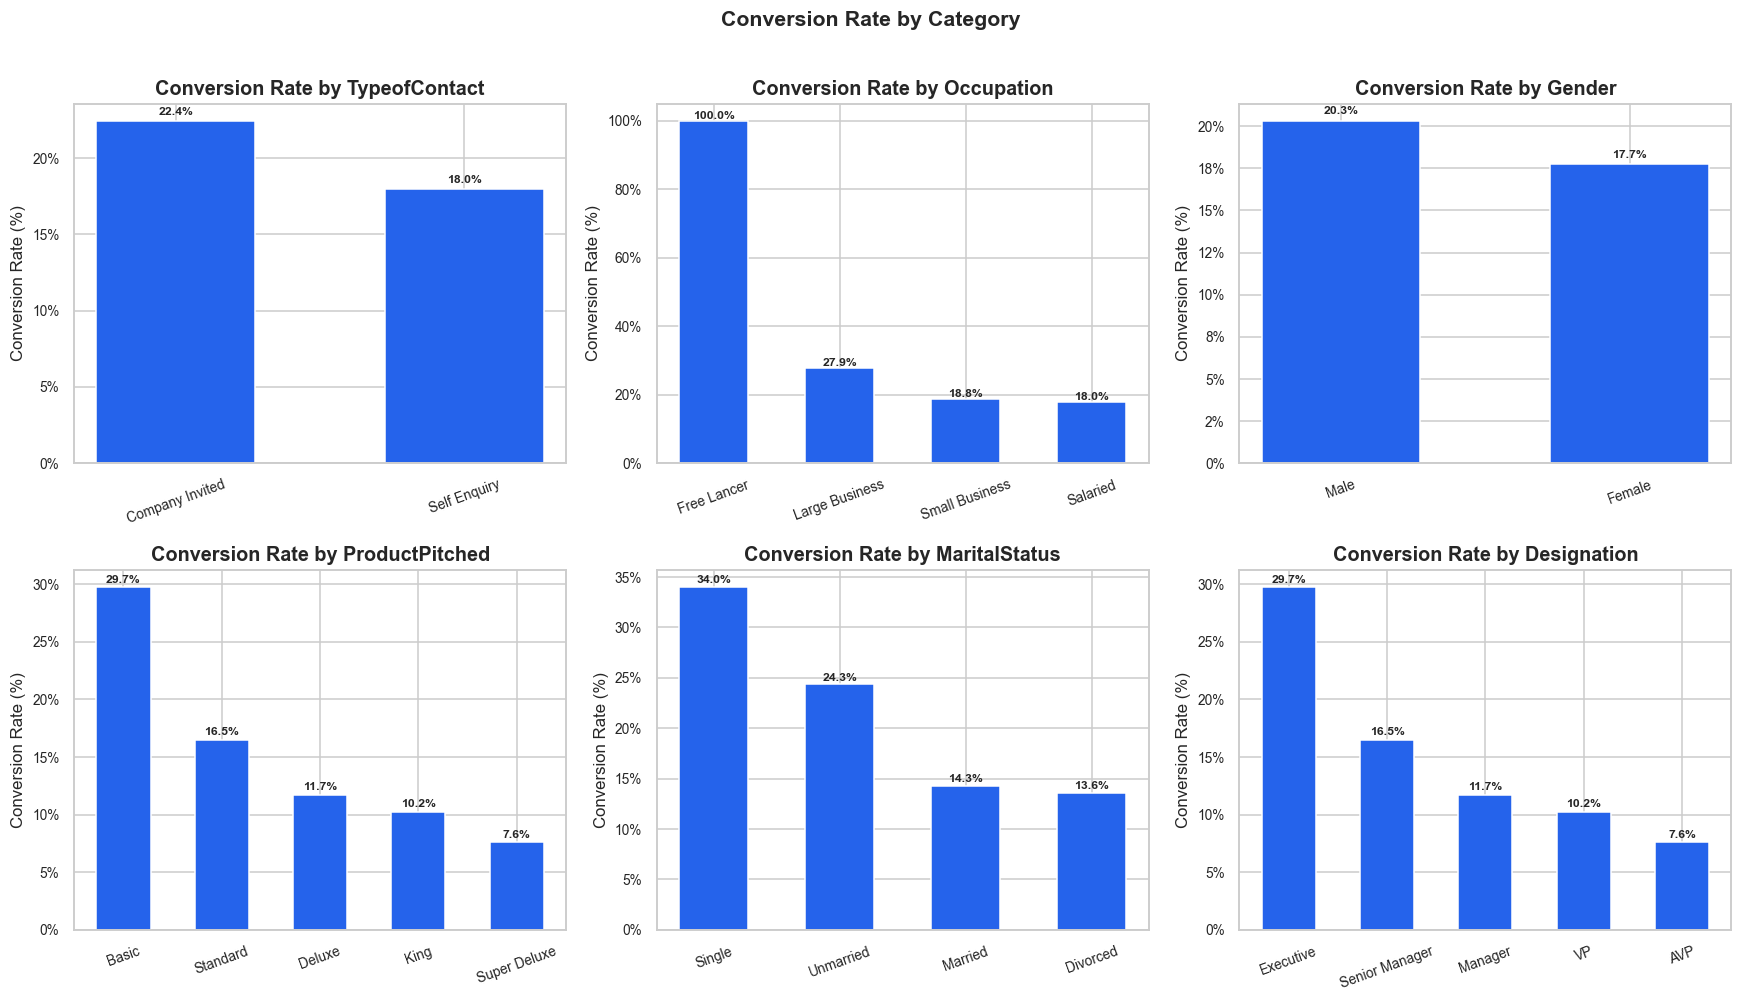

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_plot):
    conv = (df.groupby(col)[TARGET].mean() * 100).sort_values(ascending=False)
    axes[i].bar(conv.index, conv.values, color=BLUE, edgecolor='white', width=0.55)
    axes[i].set_title(f'Conversion Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Conversion Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    for j, (cat, val) in enumerate(conv.items()):
        axes[i].text(j, val + 0.4, f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')
plt.suptitle('Conversion Rate by Category', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Chart 6 — Numeric Features vs Target (Violin Plots)

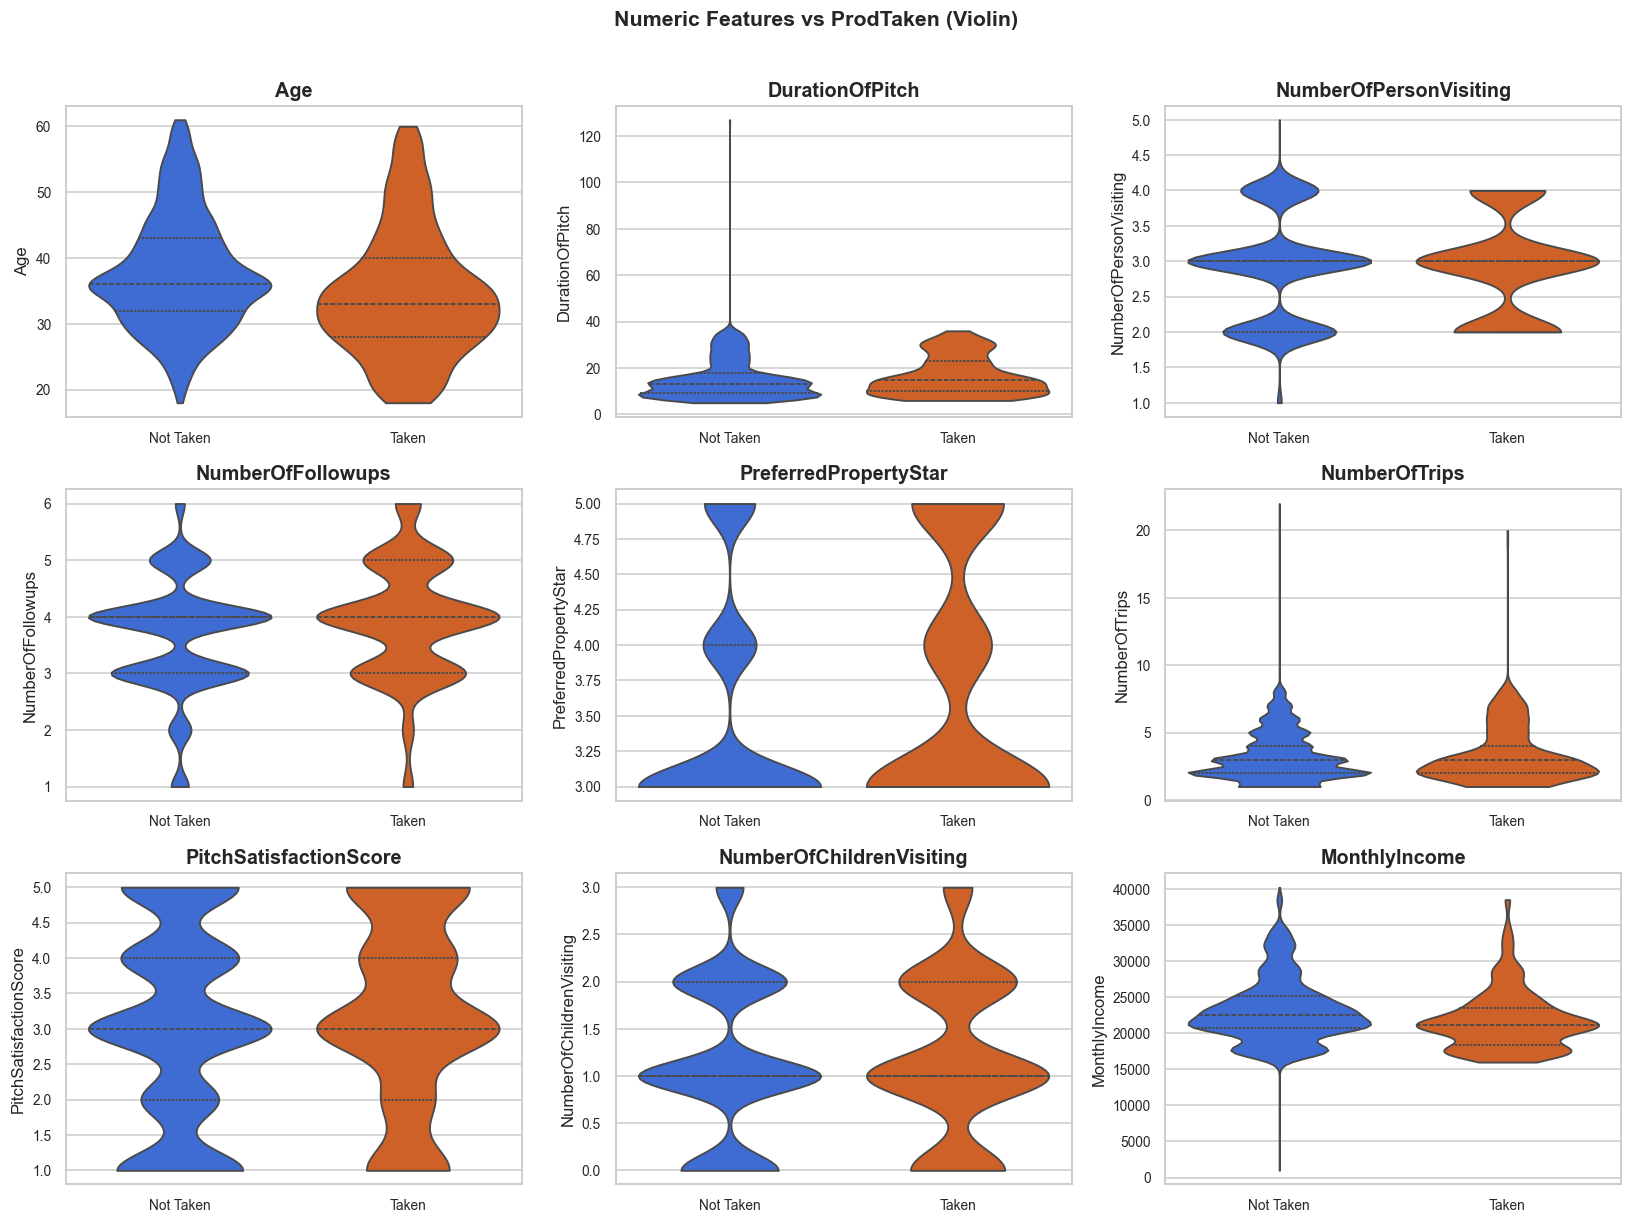

In [26]:
df_v = df.copy()
df_v['Outcome'] = df_v[TARGET].map({0: 'Not Taken', 1: 'Taken'})

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(num_plot):
    sns.violinplot(data=df_v, x='Outcome', y=col, hue='Outcome', ax=axes[i],
                   palette={'Not Taken': BLUE, 'Taken': ORANGE},
                   order=['Not Taken', 'Taken'], inner='quartile',
                   cut=0, legend=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Numeric Features vs ProdTaken (Violin)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Chart 7 — Correlation Heatmap

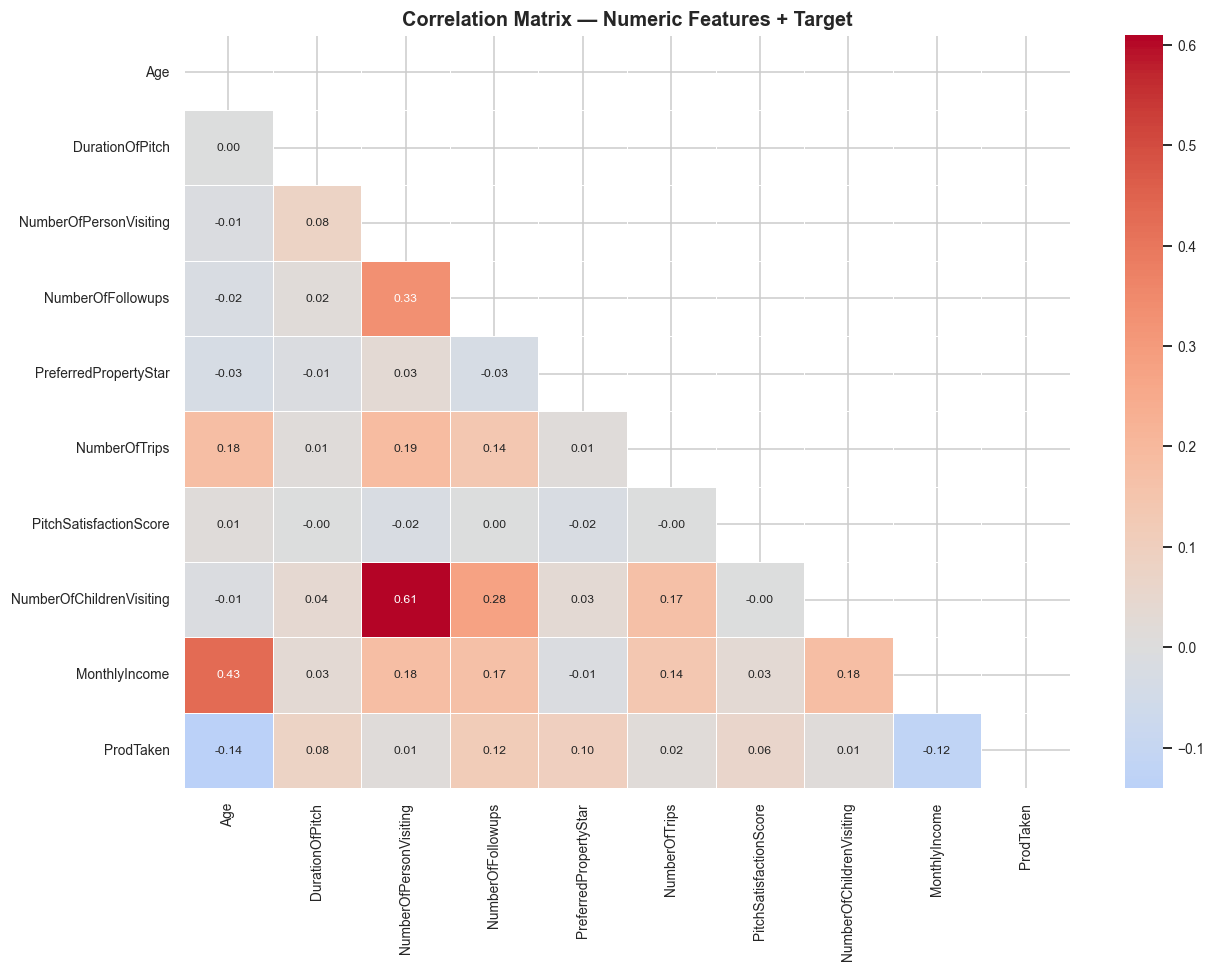

In [27]:
fig, ax = plt.subplots(figsize=(12, 9))
corr_m = df[num_plot + [TARGET]].corr().round(2)
mask = __import__('numpy').triu(__import__('numpy').ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numeric Features + Target',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Chart 8 — Top Correlations with Target (Bar)

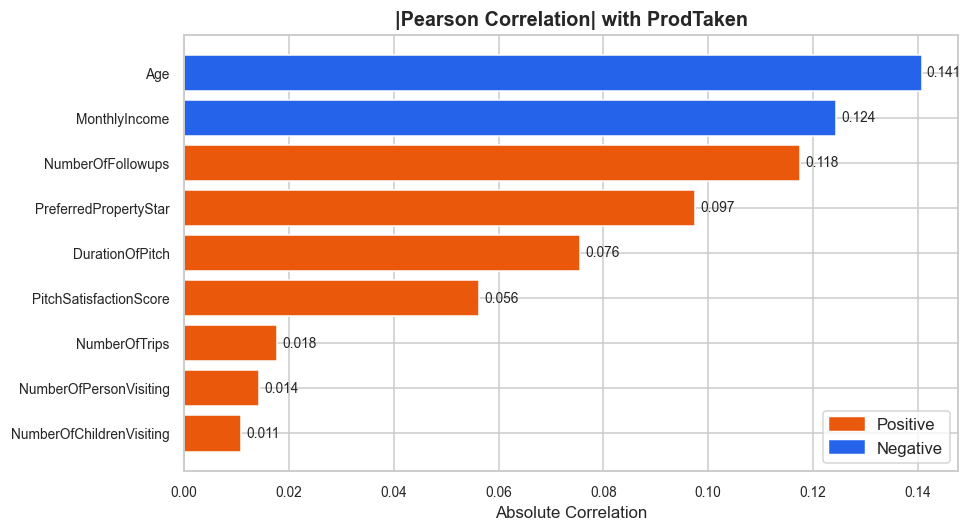

In [28]:
corr_target = df[num_plot + [TARGET]].corr()[TARGET].drop(TARGET)
corr_sorted = corr_target.abs().sort_values(ascending=True)

colors_bar = [ORANGE if corr_target[c] > 0 else BLUE for c in corr_sorted.index]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors_bar, edgecolor='white')
ax.set_title('|Pearson Correlation| with ProdTaken',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ORANGE, label='Positive'),
                    Patch(color=BLUE, label='Negative')], loc='lower right')
plt.tight_layout()
plt.show()

### Chart 9 — Age Distribution by Outcome (KDE)

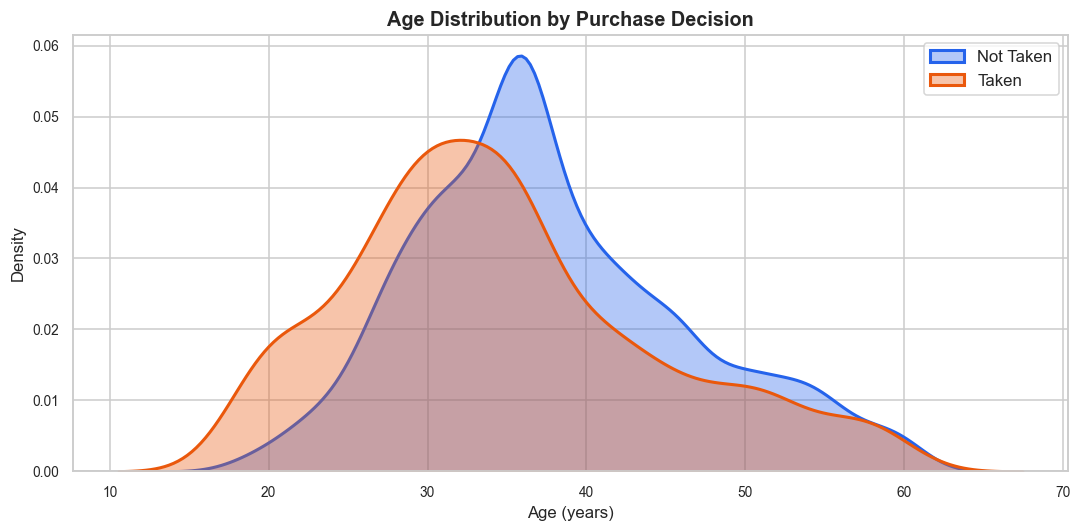

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
for val, label, color in [(0, 'Not Taken', BLUE), (1, 'Taken', ORANGE)]:
    sns.kdeplot(df[df[TARGET] == val]['Age'], ax=ax, label=label,
                color=color, fill=True, alpha=0.35, linewidth=2)
ax.set_title('Age Distribution by Purchase Decision',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Chart 10 — Monthly Income by Designation (Boxplot)

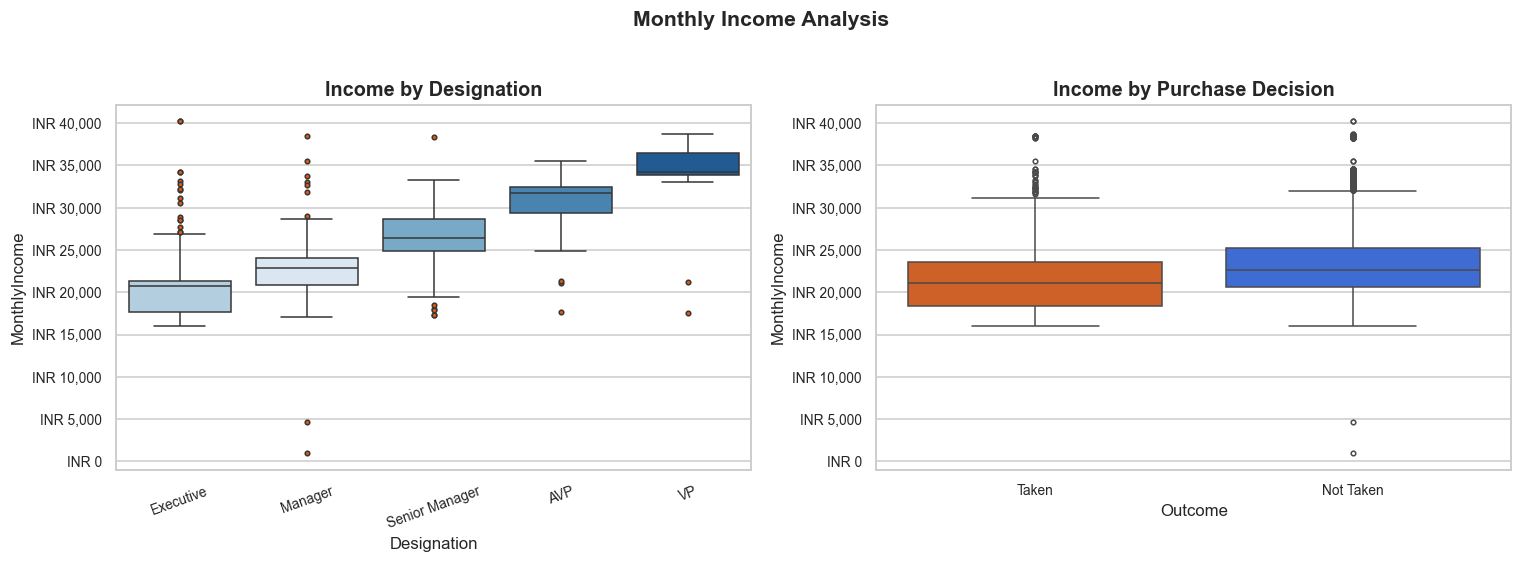

In [30]:
desg_order = df.groupby('Designation')['MonthlyIncome'].median().sort_values().index
df_v2 = df.copy()
df_v2['Outcome'] = df_v2[TARGET].map({0: 'Not Taken', 1: 'Taken'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by designation
sns.boxplot(data=df, x='Designation', y='MonthlyIncome', order=desg_order,
            hue='Designation', palette='Blues', ax=axes[0],
            legend=False,
            flierprops=dict(marker='o', markerfacecolor=ORANGE, markersize=3))
axes[0].set_title('Income by Designation', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'INR {int(x):,}'))

# Boxplot by outcome
sns.boxplot(data=df_v2, x='Outcome', y='MonthlyIncome', hue='Outcome',
            palette={'Not Taken': BLUE, 'Taken': ORANGE},
            ax=axes[1], legend=False,
            flierprops=dict(marker='o', markersize=3))
axes[1].set_title('Income by Purchase Decision', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'INR {int(x):,}'))

plt.suptitle('Monthly Income Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart 11 — Product Pitched: Stacked Conversion Bar

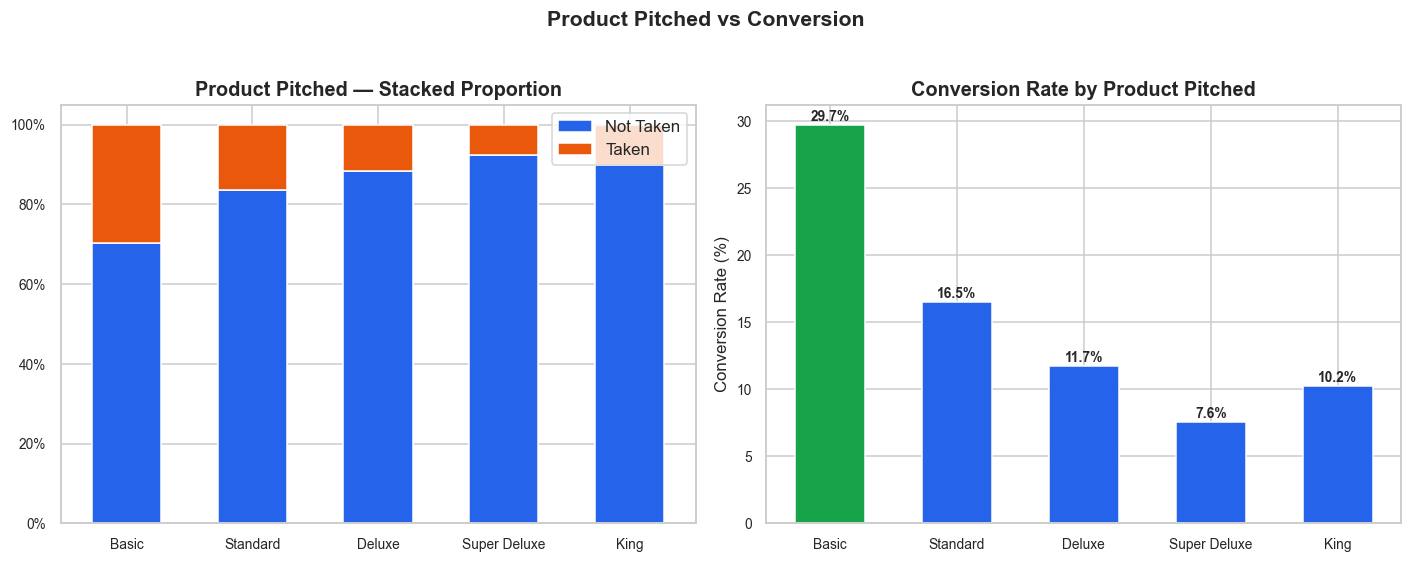

In [31]:
prod_order = ['Basic', 'Standard', 'Deluxe', 'Super Deluxe', 'King']
ct_prod = (df.groupby('ProductPitched')[TARGET]
           .value_counts(normalize=True).unstack()
           .reindex(prod_order))
ct_prod.columns = ['Not Taken', 'Taken']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_prod.plot(kind='bar', stacked=True, ax=axes[0],
             color=[BLUE, ORANGE], edgecolor='white', width=0.55)
axes[0].set_title('Product Pitched — Stacked Proportion', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend(['Not Taken', 'Taken'])

conv_prod = (df.groupby('ProductPitched')[TARGET].mean() * 100).reindex(prod_order)
bar_colors = [GREEN if v == conv_prod.max() else BLUE for v in conv_prod.values]
axes[1].bar(conv_prod.index, conv_prod.values, color=bar_colors, edgecolor='white', width=0.55)
axes[1].set_title('Conversion Rate by Product Pitched', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for j, v in enumerate(conv_prod.values):
    axes[1].text(j, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Product Pitched vs Conversion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart 12 — Passport & OwnCar vs Conversion

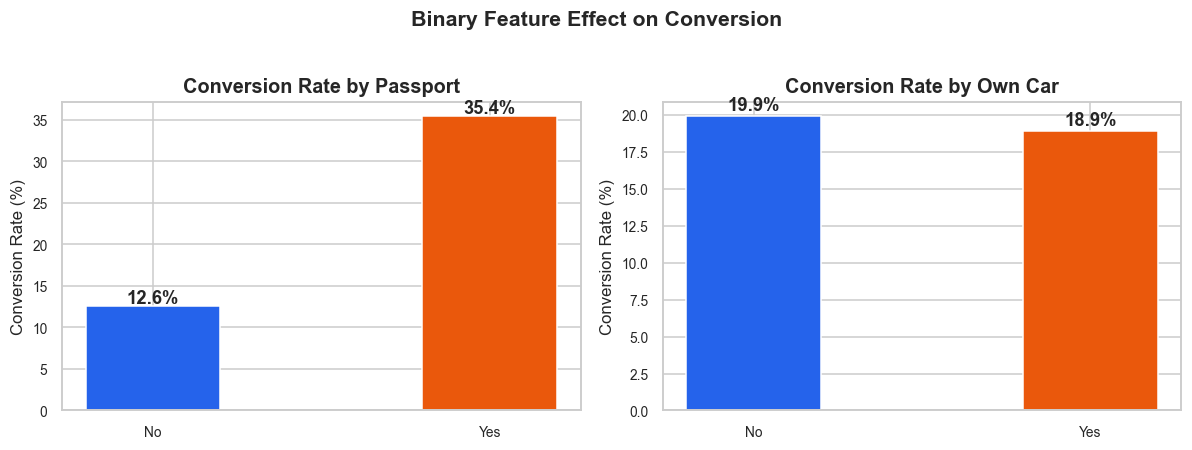

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, lbl in zip(axes, ['Passport', 'OwnCar'], ['Passport', 'Own Car']):
    conv = (df.groupby(col)[TARGET].mean() * 100)
    ax.bar(['No', 'Yes'], conv.values,
           color=[BLUE, ORANGE], edgecolor='white', width=0.4)
    ax.set_title(f'Conversion Rate by {lbl}', fontweight='bold')
    ax.set_ylabel('Conversion Rate (%)')
    for i, v in enumerate(conv.values):
        ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.suptitle('Binary Feature Effect on Conversion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Chart 13 — Age Band Conversion Rate

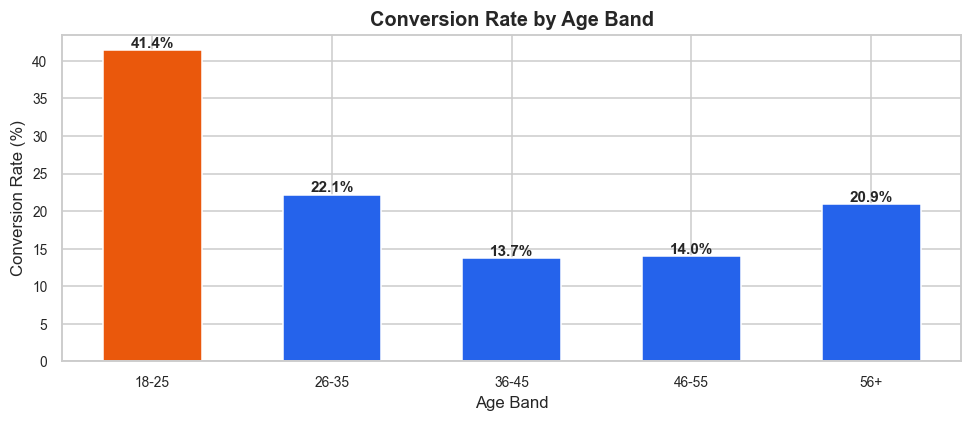

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))
age_colors = [ORANGE if v == age_df['ConversionRate'].max() else BLUE
               for v in age_df['ConversionRate']]
bars = ax.bar(age_df['AgeBand'].astype(str), age_df['ConversionRate'],
              color=age_colors, edgecolor='white', width=0.55)
ax.set_title('Conversion Rate by Age Band', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Band')
ax.set_ylabel('Conversion Rate (%)')
for bar, val in zip(bars, age_df['ConversionRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Chart 14 — Follow-ups vs Conversion Rate (Dual Axis)

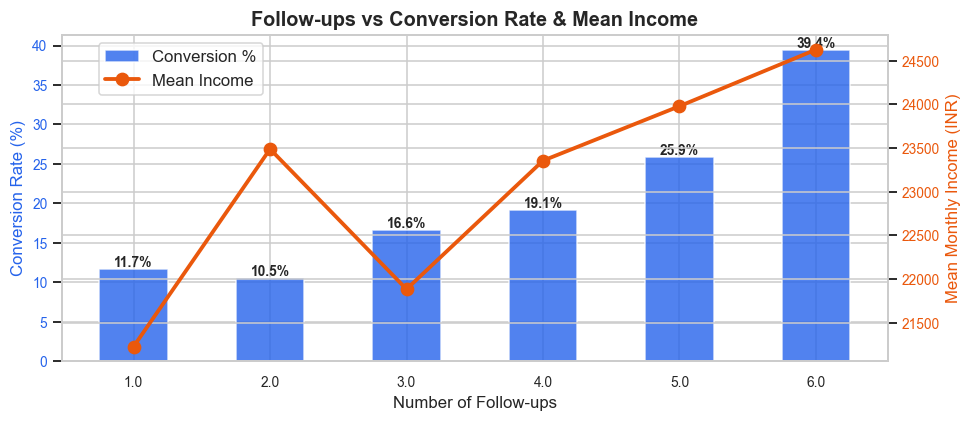

In [34]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(fu['NumberOfFollowups'].astype(str), fu['ConversionRate'],
        color=BLUE, alpha=0.8, edgecolor='white', width=0.5, label='Conversion %')
ax2.plot(fu['NumberOfFollowups'].astype(str), fu['MeanIncome'],
         color=ORANGE, marker='o', linewidth=2.5, markersize=8, label='Mean Income')

ax1.set_xlabel('Number of Follow-ups')
ax1.set_ylabel('Conversion Rate (%)', color=BLUE)
ax2.set_ylabel('Mean Monthly Income (INR)', color=ORANGE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=ORANGE)

for i, (x, y) in enumerate(zip(fu['NumberOfFollowups'].astype(str), fu['ConversionRate'])):
    ax1.text(i, y + 0.3, f'{y:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax1.set_title('Follow-ups vs Conversion Rate & Mean Income',
              fontsize=13, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

### Chart 15 — Chi-Square Results (Significance Bar)

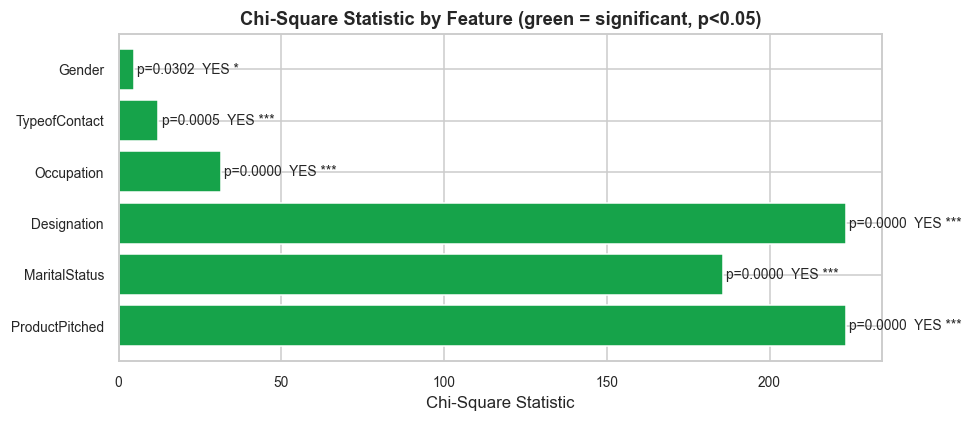

In [35]:
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [GREEN if p < 0.05 else '#cccccc' for p in chi_df['p_value']]
bars = ax.barh(chi_df['Feature'], chi_df['Chi2'], color=bar_colors, edgecolor='white')
ax.set_title('Chi-Square Statistic by Feature (green = significant, p<0.05)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Chi-Square Statistic')
for bar, (_, row) in zip(bars, chi_df.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'p={row["p_value"]:.4f}  {row["Significant"]}',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Chart 16 — T-Test Results (Significance Bar)

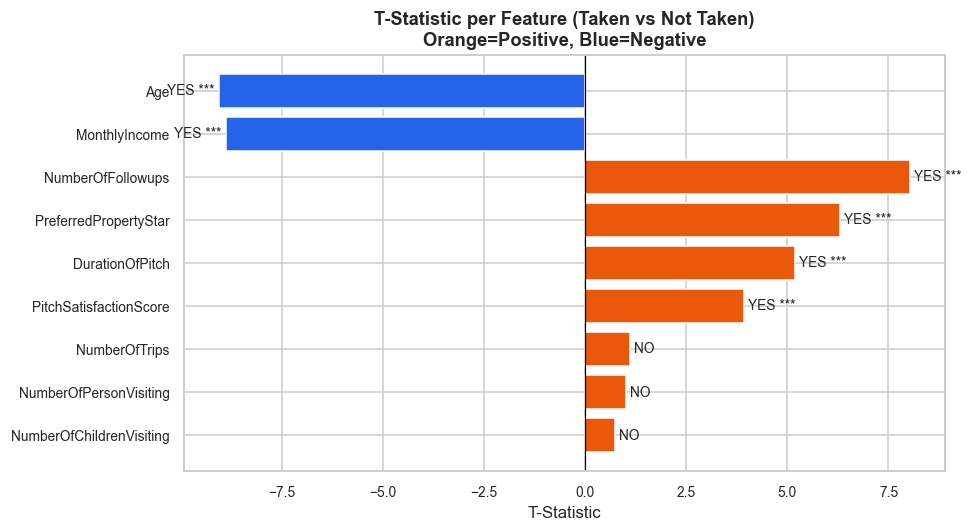

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
ttest_sorted = ttest_df.sort_values('T_Statistic', key=abs, ascending=True)
bar_colors = [ORANGE if t > 0 else BLUE for t in ttest_sorted['T_Statistic']]
bars = ax.barh(ttest_sorted['Feature'], ttest_sorted['T_Statistic'],
               color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('T-Statistic per Feature (Taken vs Not Taken)\nOrange=Positive, Blue=Negative',
             fontsize=12, fontweight='bold')
ax.set_xlabel('T-Statistic')
for bar, (_, row) in zip(bars, ttest_sorted.iterrows()):
    xpos = row['T_Statistic'] + (0.1 if row['T_Statistic'] >= 0 else -0.1)
    ha = 'left' if row['T_Statistic'] >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            row['Significant'], va='center', fontsize=9, ha=ha)
plt.tight_layout()
plt.show()

### Chart 17 — Pairplot (Key Features by Outcome)

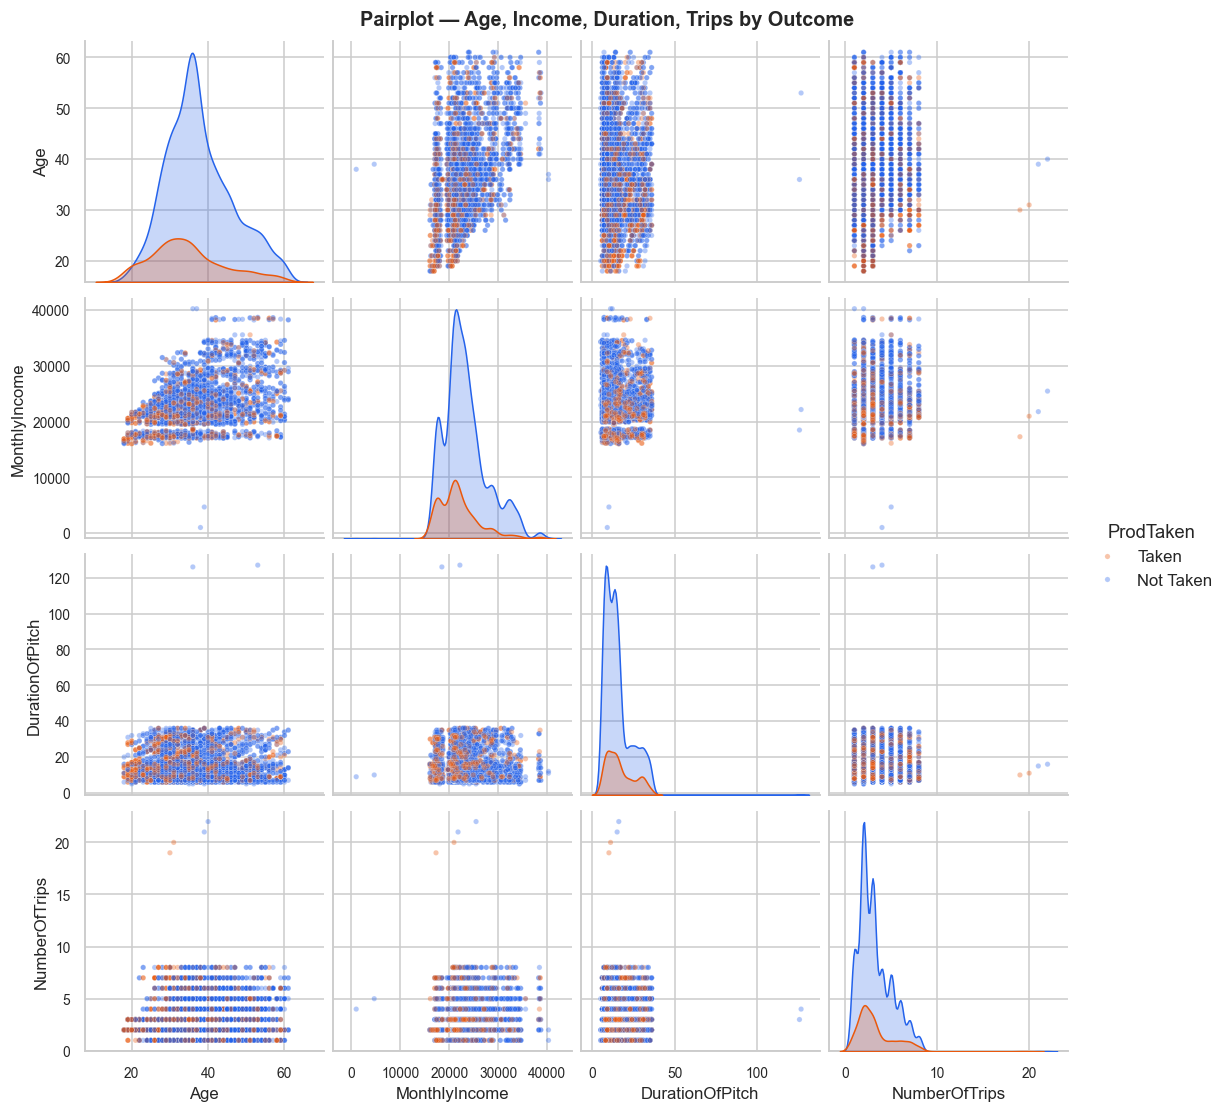

In [37]:
pair_cols = ['Age', 'MonthlyIncome', 'DurationOfPitch', 'NumberOfTrips', TARGET]
pair_df = df[pair_cols].copy()
pair_df[TARGET] = pair_df[TARGET].map({0: 'Not Taken', 1: 'Taken'})

g = sns.pairplot(pair_df, hue=TARGET,
                 palette={'Not Taken': BLUE, 'Taken': ORANGE},
                 plot_kws={'alpha': 0.35, 's': 12},
                 diag_kind='kde')
g.figure.suptitle('Pairplot — Age, Income, Duration, Trips by Outcome',
                  y=1.01, fontsize=13, fontweight='bold')
plt.show()

---
## Section 16 — Save All Reports to CSV

In [38]:
os.makedirs('analysis_report', exist_ok=True)

summary.to_csv('analysis_report/01_dataset_summary.csv', index=False)
desc.to_csv('analysis_report/02_descriptive_stats.csv')
vc.to_csv('analysis_report/03_target_distribution.csv', index=False)
conv_df.to_csv('analysis_report/04_conversion_by_category.csv', index=False)
grp_means.T.to_csv('analysis_report/05_numeric_by_target.csv')
corr_df.to_csv('analysis_report/06_correlation_with_target.csv', index=False)
outlier_df.to_csv('analysis_report/07_outlier_report.csv', index=False)
ct8.to_csv('analysis_report/08_crosstab_product_marital.csv')
ct9.to_csv('analysis_report/09_crosstab_designation_passport.csv')
inc.to_csv('analysis_report/10_income_by_designation.csv', index=False)
fu.to_csv('analysis_report/11_followup_pivot.csv', index=False)
age_df.to_csv('analysis_report/12_age_band_analysis.csv', index=False)
chi_df.to_csv('analysis_report/13_chi_square_results.csv', index=False)
ttest_df.to_csv('analysis_report/14_ttest_results.csv', index=False)

print('All 14 CSV reports saved to analysis_report/')
for f in sorted(os.listdir('analysis_report')):
    size = os.path.getsize(f'analysis_report/{f}')
    print(f'  {f:<45}  {size:>6,} bytes')

All 14 CSV reports saved to analysis_report/
  01_dataset_summary.csv                            170 bytes
  02_descriptive_stats.csv                          700 bytes
  03_target_distribution.csv                         77 bytes
  04_conversion_by_category.csv                     961 bytes
  05_numeric_by_target.csv                          368 bytes
  06_correlation_with_target.csv                    496 bytes
  07_outlier_report.csv                             514 bytes
  08_crosstab_product_marital.csv                   186 bytes
  09_crosstab_designation_passport.csv              130 bytes
  10_income_by_designation.csv                      304 bytes
  11_followup_pivot.csv                             258 bytes
  12_age_band_analysis.csv                          257 bytes
  13_chi_square_results.csv                         447 bytes
  14_ttest_results.csv                              589 bytes
  15_full_analysis_report.txt                    14,618 bytes
